# Heart Disease Prediction

This project uses the UCI Heart Disease dataset to build a binary classification model that predicts whether heart disease is present.

The original target variable ranges from 0 to 4. For this project, it is converted into:

- `0` = no heart disease
- `1` = heart disease present

The workflow includes data cleaning, exploratory data analysis, preprocessing, model training, evaluation, and comparison between Logistic Regression and Random Forest.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

## Load Dataset

In [7]:
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features.copy()
y = heart_disease.data.targets.copy()

X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


In [8]:
y.head()

,num
0,0
1,2
2,1
3,0
4,0


## Initial Data Inspection

The dataset contains 303 patient records, 13 input features, and one target variable.

In [9]:
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (303, 13)
Target shape: (303, 1)


In [10]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 30.9 KB


In [11]:
X.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


In [12]:
y["num"].value_counts()

num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

## Data Cleaning

The dataset contains missing values in the `ca` and `thal` columns.

Because both variables are categorical/discrete in meaning, the missing values are filled using the mode of each column.

In [14]:
X.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64

In [13]:
X["ca"] = X["ca"].fillna(X["ca"].mode()[0])
X["thal"] = X["thal"].fillna(X["thal"].mode()[0])

X.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64

## Exploratory Data Analysis

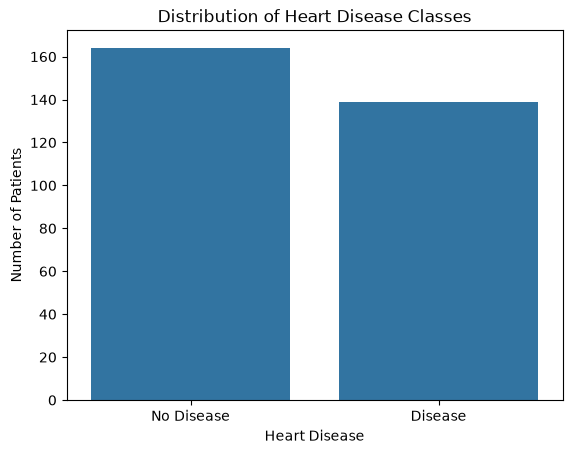

In [15]:
y_binary = (y["num"] > 0).astype(int)

sns.barplot(
    x=y_binary.value_counts().index,
    y=y_binary.value_counts().values
)

plt.xticks([0, 1], ["No Disease", "Disease"])
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")
plt.title("Distribution of Heart Disease Classes")
plt.show()

The target distribution is fairly balanced:

- approximately 54% no disease
- approximately 46% disease

Because the classes are already close in size, no special class-balancing technique is necessary.

## Target Preparation

The original target ranges from 0 to 4.

For binary classification:

- `0` remains `0`
- values greater than `0` become `1`

In [16]:
y_binary = (y["num"] > 0).astype(int)
y_binary.value_counts()

num
0    164
1    139
Name: count, dtype: int64

## Train/Test Split

The data is split into training and testing sets using an 80/20 split.

Stratification is used to preserve the original class proportions in both sets.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

num
0    0.541322
1    0.458678
Name: proportion, dtype: float64
num
0    0.540984
1    0.459016
Name: proportion, dtype: float64


## Logistic Regression

Logistic Regression is used as a baseline classification model.

Because it is sensitive to feature scale, the input features are standardized using `StandardScaler`.

The scaler is fitted only on the training data to avoid data leakage.

In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
logreg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logreg.fit(X_train_scaled, y_train)

logreg_pred = logreg.predict(X_test_scaled)
logreg_prob = logreg.predict_proba(X_test_scaled)[:, 1]

In [22]:
logreg_accuracy = accuracy_score(y_test, logreg_pred)
logreg_precision = precision_score(y_test, logreg_pred)
logreg_recall = recall_score(y_test, logreg_pred)
logreg_f1 = f1_score(y_test, logreg_pred)
logreg_auc = roc_auc_score(y_test, logreg_prob)

print("Accuracy:", logreg_accuracy)
print("Precision:", logreg_precision)
print("Recall:", logreg_recall)
print("F1:", logreg_f1)
print("ROC-AUC:", logreg_auc)

Accuracy: 0.8688524590163934
Precision: 0.8125
Recall: 0.9285714285714286
F1: 0.8666666666666667
ROC-AUC: 0.9512987012987013


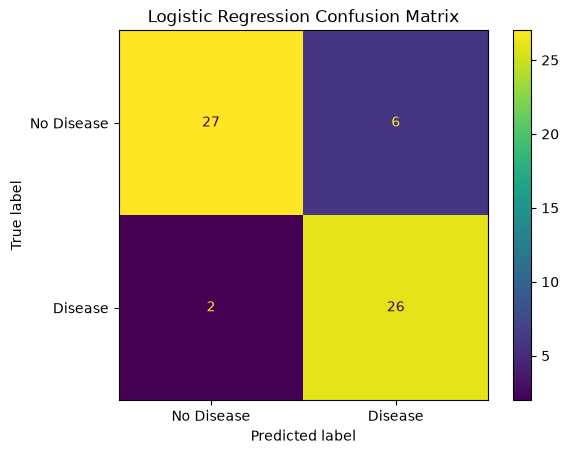

In [23]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    logreg_pred,
    display_labels=["No Disease", "Disease"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

## Random Forest

Random Forest is trained as a second classification model for comparison.

Although tree-based models do not require feature scaling, the same scaled data is used here for consistency with the existing workflow.

In [24]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_test_scaled)
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

In [25]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1:", rf_f1)
print("ROC-AUC:", rf_auc)

Accuracy: 0.8852459016393442
Precision: 0.8181818181818182
Recall: 0.9642857142857143
F1: 0.8852459016393442
ROC-AUC: 0.9512987012987013


In [26]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Logistic Regression": [
        logreg_accuracy,
        logreg_precision,
        logreg_recall,
        logreg_f1,
        logreg_auc
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_auc
    ]
})

results

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.868852,0.885246
1,Precision,0.812500,0.818182
2,Recall,0.928571,0.964286
3,F1,0.866667,0.885246
4,ROC-AUC,0.951299,0.951299


## Model Selection

Random Forest achieved slightly stronger overall performance, particularly in recall and F1-score.

Because recall is especially important in a screening-style classifier, Random Forest was selected as the final model for the Streamlit application.

The dataset is relatively small, so these test results should be interpreted cautiously and should not be treated as clinical validation.

## Conclusion

This project developed a binary heart-disease classifier using the UCI Heart Disease dataset.

Key findings:

- The dataset was relatively balanced between disease and non-disease cases.
- Missing values were limited to `ca` and `thal` and were filled using the mode.
- Several features showed useful relationships with the target, including `thal`, `ca`, `exang`, `oldpeak`, `cp`, and `thalach`.
- Both Logistic Regression and Random Forest performed well.
- Random Forest achieved the strongest recall and F1-score and was selected for deployment.

This project is intended for educational and portfolio purposes only and is not a medical diagnostic tool.

In [28]:
joblib.dump(rf_model, "random_forest_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']